# Eksik Gözlem Nasıl Tespit Edilir?
Bir önceki konuda temel `isnull().sum()` komutunu gördük. Şimdi, eksik 
değerleri **daha derinlemesine keşfetmenin** pratik yollarını ele 
alıyoruz — çünkü "kaç tane eksik var" sorusu yeterli değil, "eksikler 
NEREDE ve NASIL dağılmış" sorusu da önemli.

## 1. Temel Sayım (Zaten Bildiğimiz)
```python
df.isnull().sum()
df.isnull().sum() / len(df) * 100  # yüzde olarak
```

## 2. Satır Bazlı Eksiklik
Bazı satırlarda **birden fazla** kolon eksik olabilir — bu satırlar 
"tamamen sorunlu" satırlar olabilir:
```python
df.isnull().sum(axis=1)  # her satırda kaç eksik değer var
df[df.isnull().sum(axis=1) > 2]  # 2'den fazla eksiği olan satırlar
```

## 3. Görsel İnceleme (missingno)
```python
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df)   # her satır/kolonu görsel bir harita gibi gösterir, 
                   # eksik değerler beyaz boşluk olarak görünür
plt.show()

msno.bar(df)       # her kolonun ne kadar dolu olduğunu bar chart ile gösterir
msno.heatmap(df)   # kolonlar arası eksiklik KORELASYONUNU gösterir - 
                   # "A eksikse B'nin de eksik olma ihtimali yüksek mi?"
```

## Neden `msno.heatmap()` Özellikle Değerli?
Bu, Korelasyon bölümünde öğrendiğimiz korelasyon mantığının, 
**eksiklik örüntülerine** uygulanmış hali! İki kolonun **eksik olma 
durumları arasında** korelasyon varsa (örn: "Telefon numarası eksikse, 
Email de genelde eksik"), bu, eksikliklerin **rastgele olmadığını**, 
belki ortak bir kaynaktan (örn: "bu kayıtlar hep aynı formdan gelmiş, o 
form bu iki alanı da içermiyormuş") geldiğini gösterebilir — bu da bir 
sonraki konudaki (MCAR/MAR/MNAR) sınıflandırmaya ipucu verir.

## Pratik İş Akışı
1. Önce `isnull().sum()` ile genel tablo
2. `msno.matrix()` ile görsel örüntüyü inceliyoruz (rastgele mi, gruplu mu?)
3. `msno.heatmap()` ile kolonlar arası eksiklik ilişkisine bakıyoruz
4. Bulgulara göre, eksikliğin türünü (MCAR/MAR/MNAR) değerlendirmeye geçilir.

Eksik Değer Sayıları:
Musteri_ID     0
Yas            0
Gelir         20
Telefon       34
Email         39
Memnuniyet     0
dtype: int64

Eksik Değer Yüzdeleri:
Musteri_ID     0.0
Yas            0.0
Gelir         10.0
Telefon       17.0
Email         19.5
Memnuniyet     0.0
dtype: float64


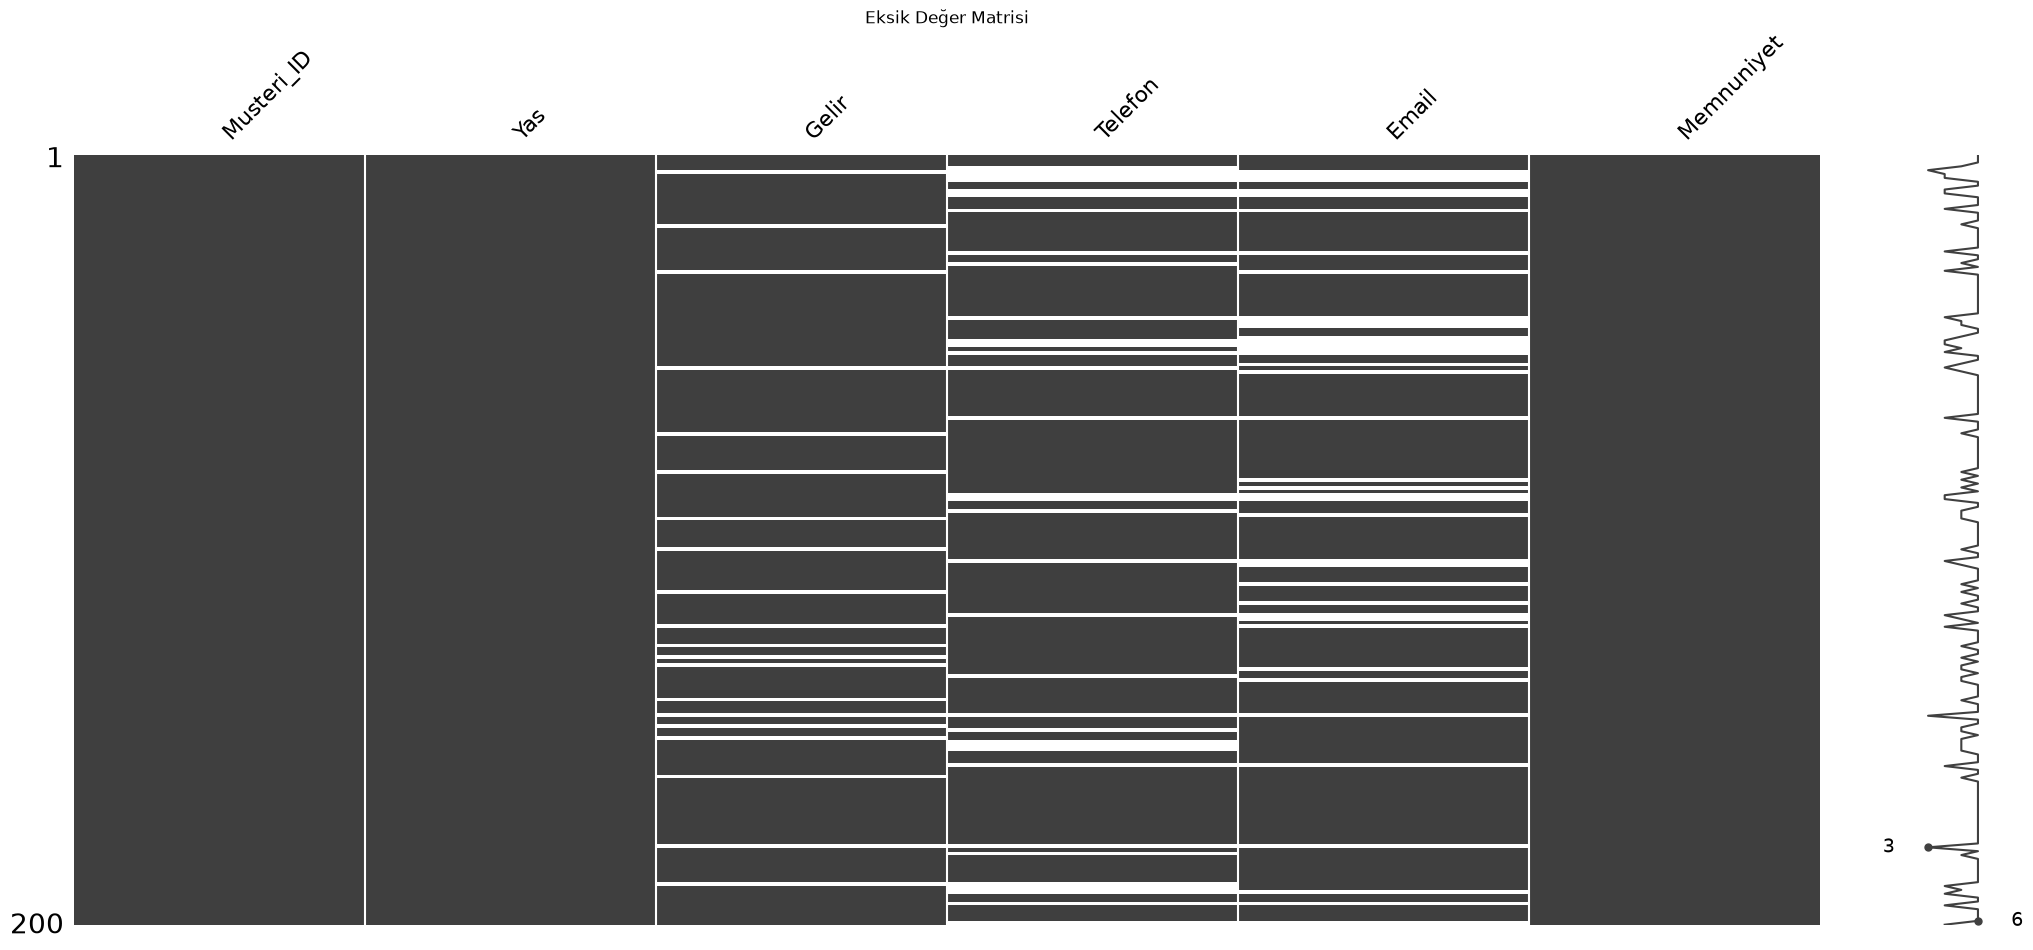

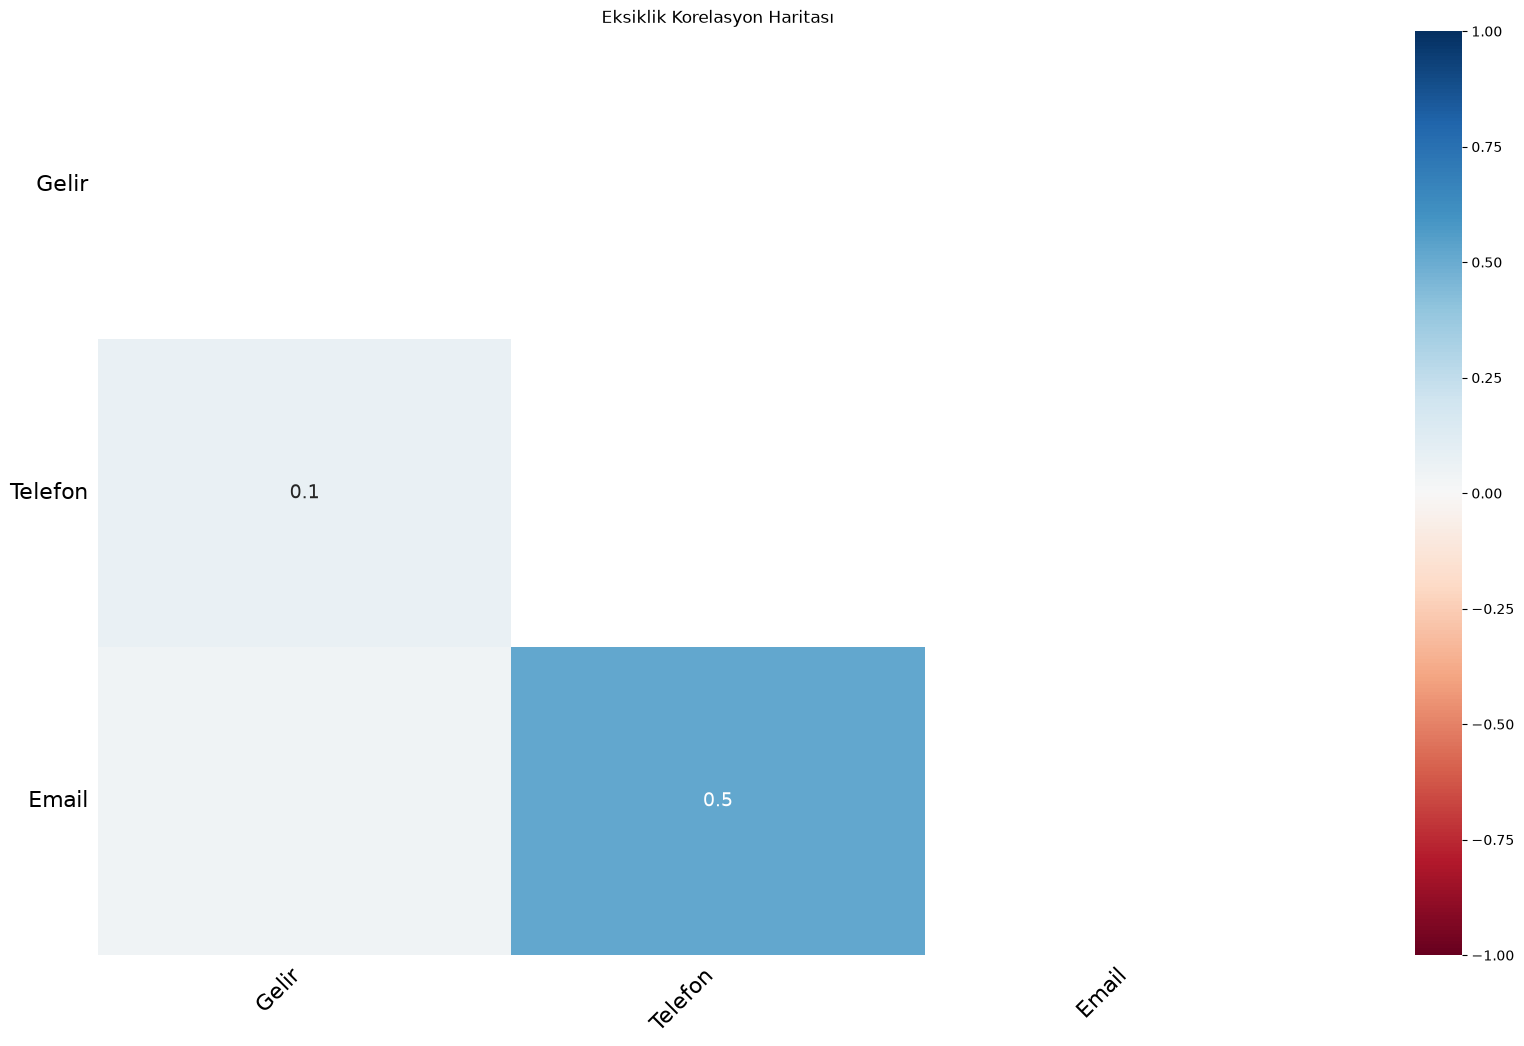

In [1]:
import numpy as np
import pandas as pd
import missingno as msno
import matplotlib.pyplot as plt

np.random.seed(42)
n = 200

# --- Veri Oluşturma ---
df = pd.DataFrame({
    'Musteri_ID': np.arange(1, n+1),
    'Yas': np.random.normal(35, 10, n),
    'Gelir': np.random.normal(5000, 1500, n),
    'Telefon': np.random.choice(['555-1234','555-5678', None], n, p=[0.4,0.4,0.2]),
    'Email': [None]*n,
    'Memnuniyet': np.random.normal(70, 15, n)
})

# Telefon eksikse, Email'in de eksik olma ihtimalini bilerek yüksek tutuyoruz (ilişkili eksiklik)
for i in range(n):
    if pd.isna(df.loc[i, 'Telefon']):
        df.loc[i, 'Email'] = None if np.random.random() < 0.85 else f"musteri{i}@mail.com"
    else:
        df.loc[i, 'Email'] = f"musteri{i}@mail.com" if np.random.random() < 0.9 else None

# Gelir'de ise TAMAMEN RASTGELE eksiklik (Telefon/Email ile hiç ilişkisi yok)
gelir_eksik_idx = np.random.choice(n, size=20, replace=False)
df.loc[gelir_eksik_idx, 'Gelir'] = np.nan

# --- 1. Temel Sayım ---
print("Eksik Değer Sayıları:")
print(df.isnull().sum())

print("\nEksik Değer Yüzdeleri:")
print((df.isnull().sum() / len(df) * 100).round(2))

# --- 2. Görsel İnceleme: Matrix ---
msno.matrix(df)
plt.title("Eksik Değer Matrisi")
plt.show()

# --- 3. Görsel İnceleme: Heatmap (Kolonlar Arası Eksiklik İlişkisi) ---
msno.heatmap(df)
plt.title("Eksiklik Korelasyon Haritası")
plt.show()

Yukarıdaki 2 görseli incelediğimizde telefon sütununa ait boş gözlemler ile email sütununa ait boş gözlemler arasında 0.5 oranında orta düzeyde bir ilişki olduğunu görüyoruz. Yani bazı kişiler telefon bilgisini girmediğinde email bilgilerini de girmemiş olabilir. Bu sorun iletişim formunun bir kısmının boş bırakılmasından kaynaklanmış olabilir. 1. görselde de telefon ve email kısmında beyaz çizgilerin genelde yan yana dizildiğini yani birlikte boş olduklarını görüyoruz. 